# Board Level Strategic Insight Request
## Data Analyst: Rimalyn Magallamento BSIS-4B
## Date of Request: September 29, 2025

Scenario

A mid-sized financial institution has been actively expanding its personal loan portfolio. However, recent shifts in customer behavior and credit risk profiles have prompted the Board of Directors to revisit the underlying factors influencing loan approvals and amounts granted. The board is particularly concerned with credit risk, profitability, and data-driven decision-making.

During a quarterly strategy meeting, the Chief Risk Officer (CRO) presents a dashboard highlighting inconsistencies in the average loan amounts issued across customer segments. Some applicants with moderate income and lower credit scores are receiving higher-than-expected loan amounts, while more qualified applicants appear to be under-leveraged.

In response, the Chairperson of the Board raises a crucial question:

"Among all the customer attributes we’ve been collecting—like income, credit score, employment history, age, debt-to-income ratio, and education level—can we clearly identify which of these factors have the strongest statistical relationship with the loan amount issued?"

The board mandates the Data Analytics Team to conduct an immediate correlation analysis to:

1. Identify which factors most strongly drive loan amounts.

2. Distinguish between statistically significant vs. insignificant variables.

3. Support future decisions about automating loan approvals, tightening risk thresholds, or tailoring products to specific customer profiles.

Create a Business Analytics Report that address the request of the board.

In [ ]:
!pip install seaborn
!pip install matplotlib.pyplot
!pip install qdesc
!pip install os

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot
ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import qdesc as qd
import os

# **EXPLORATORY DATA** **ANALYSIS**

In [ ]:
os.chdir('/content/sample_data/')
df = pd.read_excel("HypotheticalLoansData.xlsx")
df.head()

,Income,CreditScore,EmploymentYears,DebtToIncome,Age,EducationLevel,LoanAmount
0,67450.71,746.31,22,0.27,48,Bachelor,105119.57
1,57926.04,795.47,11,0.38,59,Bachelor,104818.75
2,69715.33,630.07,16,0.37,26,Bachelor,99397.74
3,82845.45,728.15,7,0.23,29,High School,99163.53
4,56487.70,667.47,10,0.38,40,High School,80141.29


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Income           500 non-null    float64
 1   CreditScore      500 non-null    float64
 2   EmploymentYears  500 non-null    int64  
 3   DebtToIncome     500 non-null    float64
 4   Age              500 non-null    int64  
 5   EducationLevel   500 non-null    object 
 6   LoanAmount       500 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 27.5+ KB


In [ ]:
df.head(10)

,Income,CreditScore,EmploymentYears,DebtToIncome,Age,EducationLevel,LoanAmount
0,67450.71,746.31,22,0.27,48,Bachelor,105119.57
1,57926.04,795.47,11,0.38,59,Bachelor,104818.75
2,69715.33,630.07,16,0.37,26,Bachelor,99397.74
3,82845.45,728.15,7,0.23,29,High School,99163.53
4,56487.70,667.47,10,0.38,40,High School,80141.29
5,56487.95,675.64,28,0.24,21,Master,80524.89
6,83688.19,670.38,2,0.48,28,Bachelor,77519.47
7,71511.52,656.80,26,0.22,43,High School,86387.21
8,52957.88,702.43,5,0.32,23,Master,74900.95
9,68138.40,658.45,8,0.22,24,High School,102339.46


# **DESCRIPTIVE STATISTICS**

In [ ]:
desc = df.describe()
desc.T

,count,mean,std,min,25%,50%,75%,max
Income,500.0,60102.56978,14718.798391,11380.99,49495.3900,60191.96,69551.7525,117790.97
CreditScore,500.0,701.59120,48.900041,565.16,670.2350,701.43,732.5625,831.62
EmploymentYears,500.0,14.31200,8.517026,0.00,7.0000,14.00,22.0000,29.00
DebtToIncome,500.0,0.29890,0.096851,0.01,0.2300,0.30,0.3600,0.57
Age,500.0,42.54400,12.714219,21.00,31.7500,42.50,54.0000,64.00
LoanAmount,500.0,87561.53296,13021.297761,53960.78,78285.4825,87579.97,96888.5175,119076.87


Interpretation:

The descriptive statistics provide a summary of 500 observations across all variables.

Income: The average income is around 60,102, with a wide range from 11,381 to 117,791. The spread (std = 14,719) shows substantial variability in earnings across individuals.

Credit Score: The mean credit score is 701, with values ranging from 565 to 832. The distribution is fairly consistent (std = 49), indicating most individuals fall within a healthy credit score range.

Employment Years: On average, individuals have 14 years of employment. The distribution ranges from 0 to 29 years, with a median of 14, suggesting balanced representation between early and late career stages.

Debt-to-Income Ratio: The mean debt-to-income ratio is 0.30, with most values between 0.23 and 0.36. The relatively small spread (std = 0.097) implies that debt burden levels are fairly consistent among individuals.

Age: The average age is 42.5 years, ranging from 21 to 64. The quartiles show most individuals are in their early 30s to mid-50s, reflecting a working-age population.

Loan Amount: The average loan amount is approximately 87,562, with values between 53,961 and 119,067. The standard deviation (13,021) indicates a moderate variation, and most loans cluster between ~78,285 and ~96,889.

## **NORMALITY CHECK**


--- Variable: Income ---
  Anderson-Darling Statistic : 0.2978
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


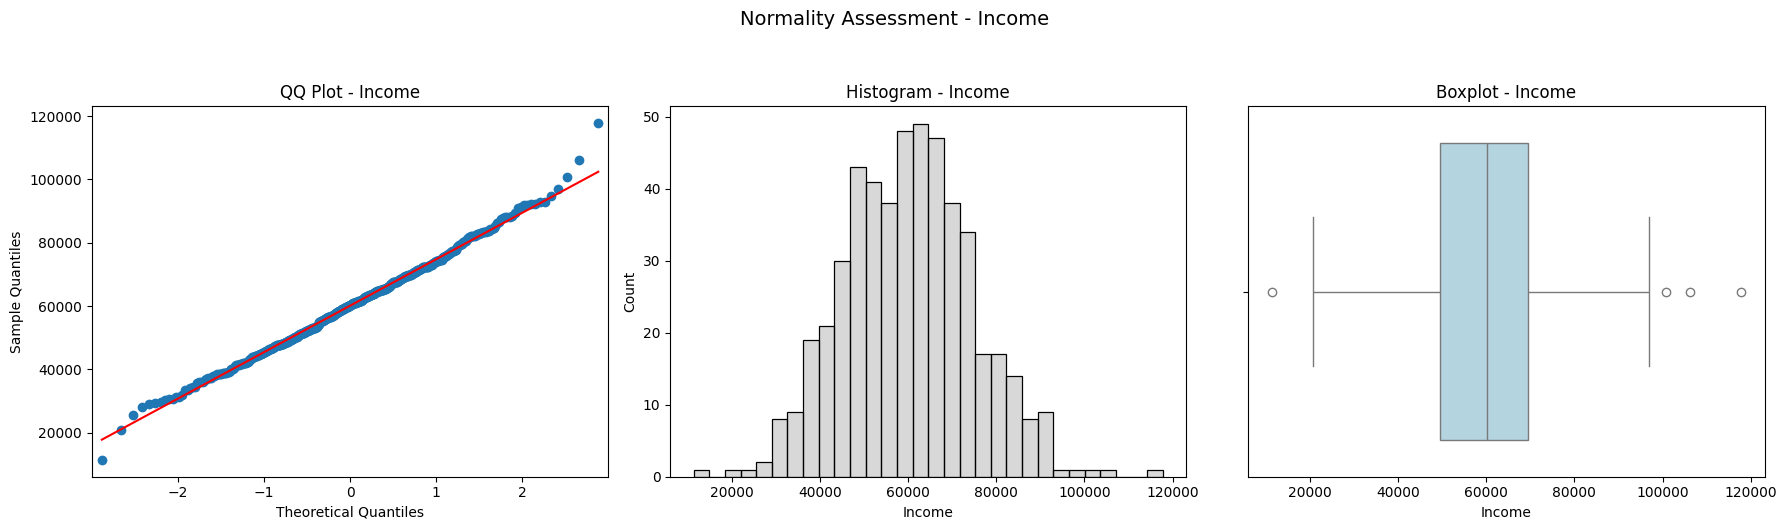


--- Variable: CreditScore ---
  Anderson-Darling Statistic : 0.2349
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


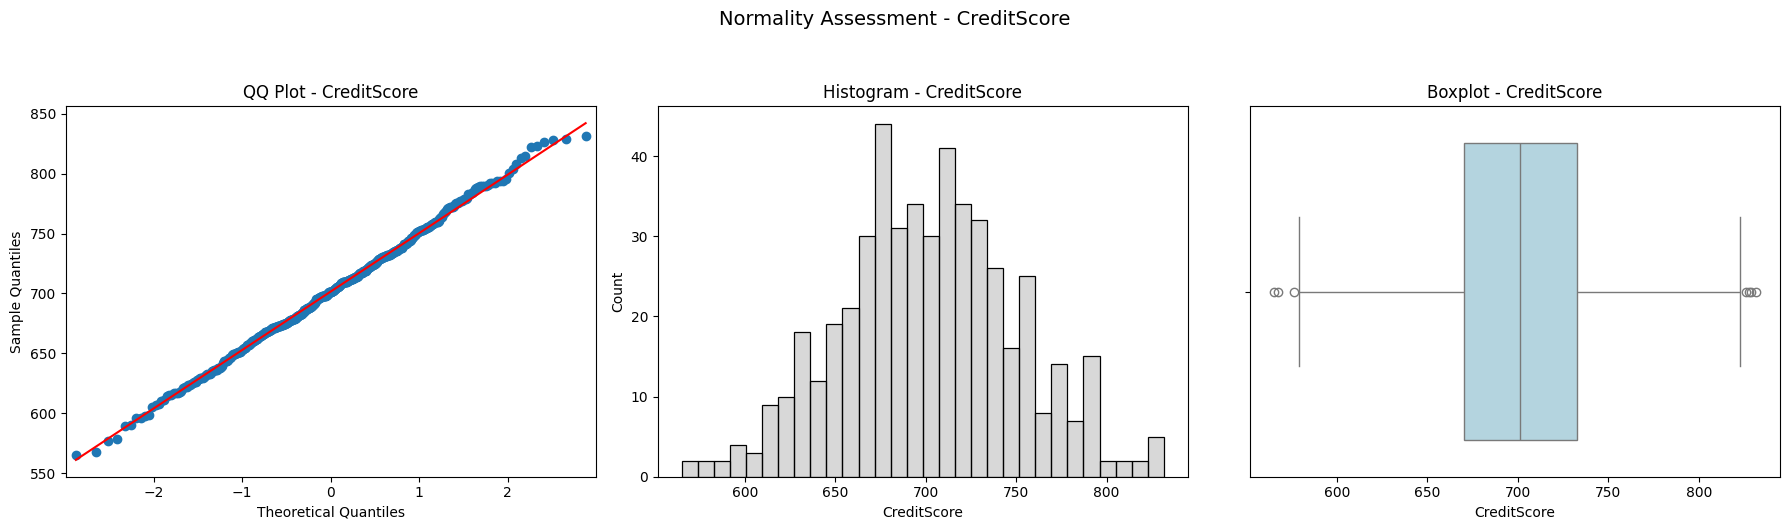


--- Variable: EmploymentYears ---
  Anderson-Darling Statistic : 5.2192
  Critical Value (@ 5.0%) : 0.7810
  Decision : Reject Null


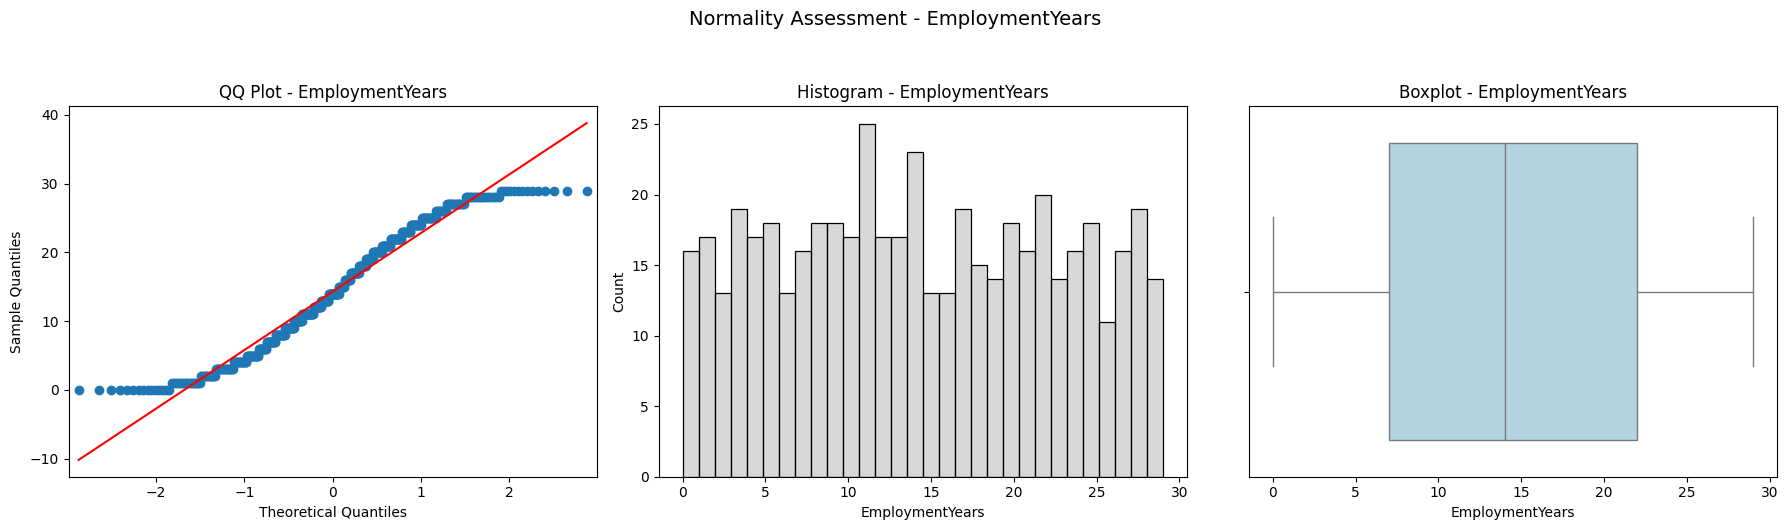


--- Variable: DebtToIncome ---
  Anderson-Darling Statistic : 0.4250
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


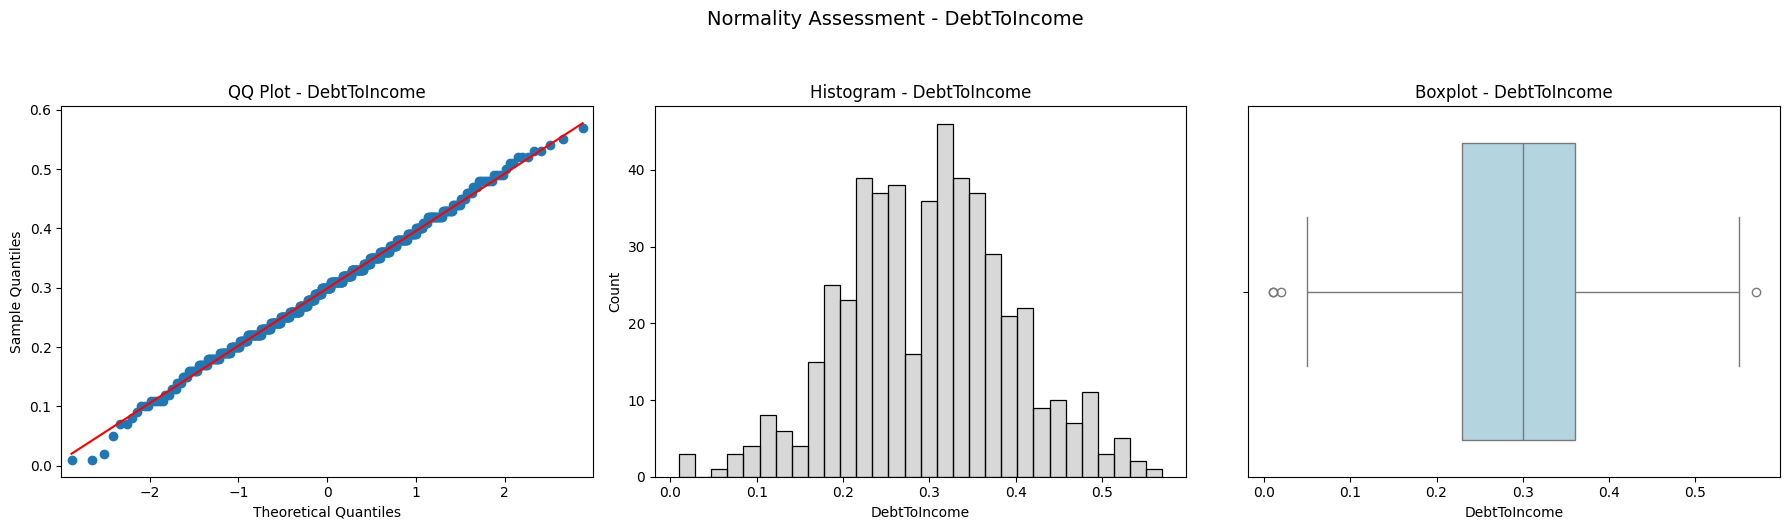


--- Variable: Age ---
  Anderson-Darling Statistic : 6.4294
  Critical Value (@ 5.0%) : 0.7810
  Decision : Reject Null


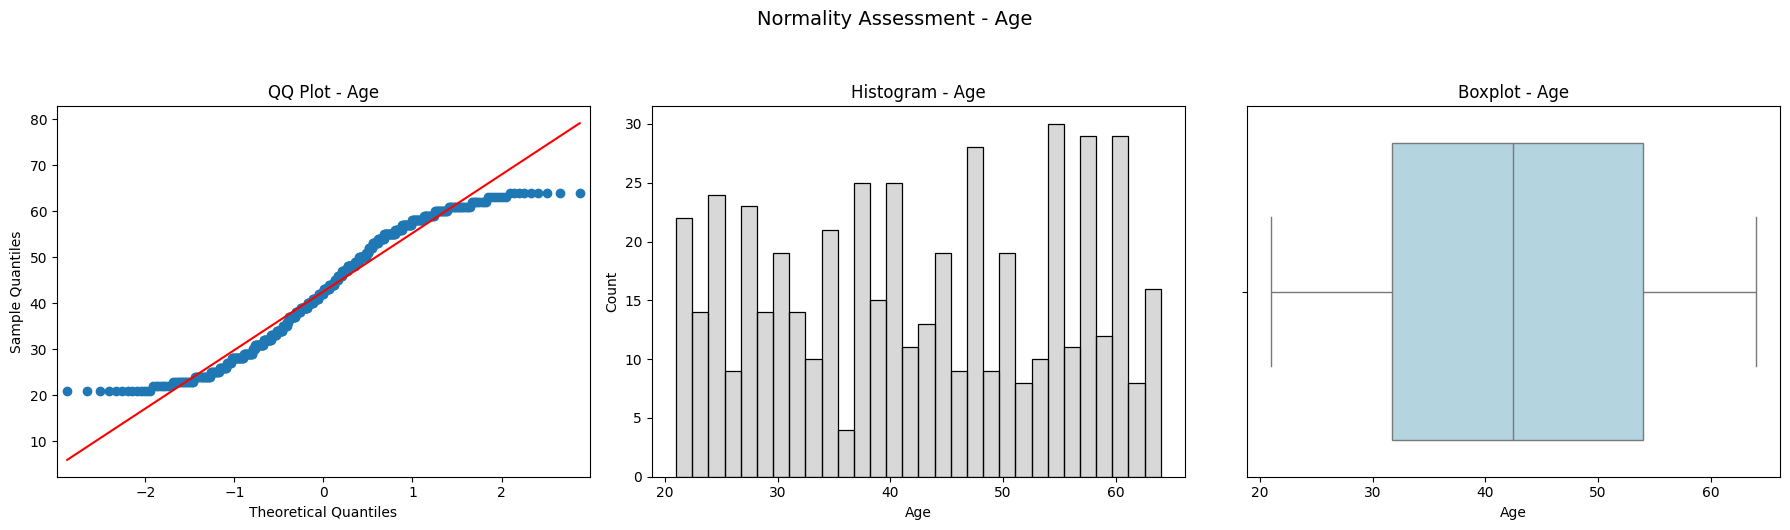


--- Variable: LoanAmount ---
  Anderson-Darling Statistic : 0.2794
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


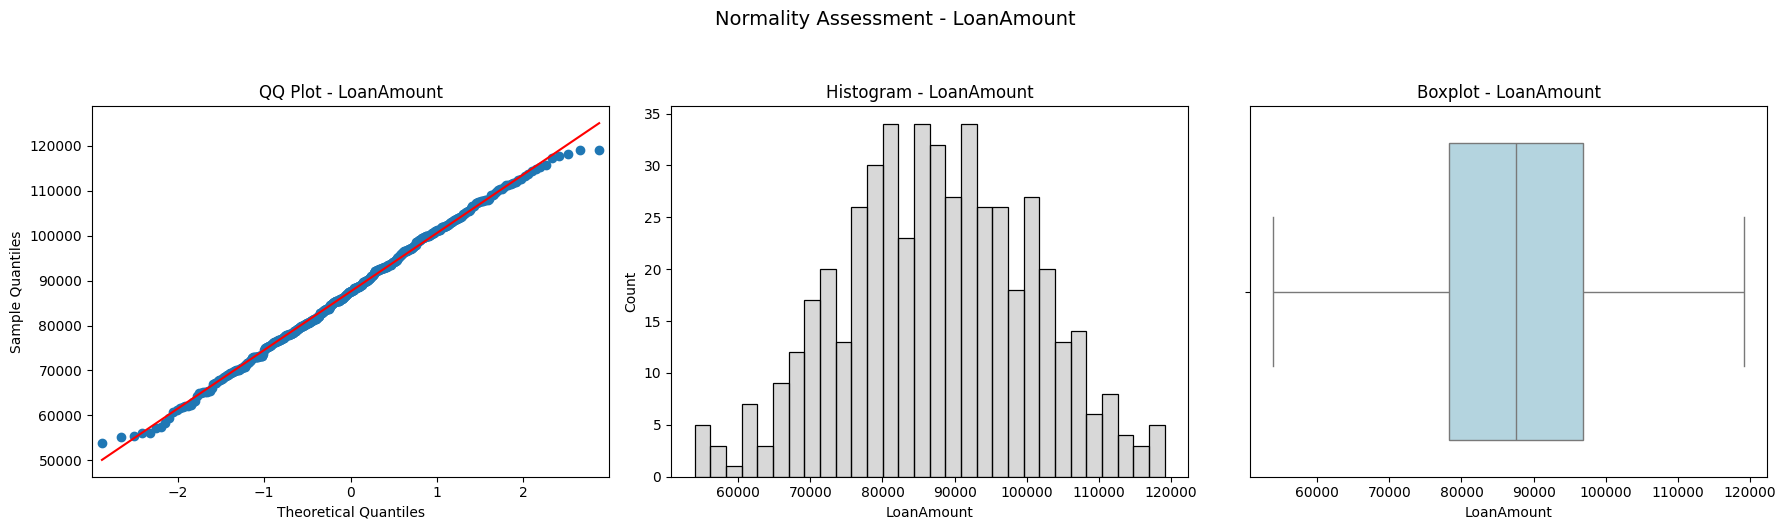

In [ ]:
qd.normcheck_dashboard(df)

Interpretation:


1. ***Income***

*   Anderson-Darling Statistic = 0.2978 < Critical Value (0.7810)
Decision: Fail to Reject Null Hypothesis → Approximately Normally Distributed.
*   QQ Plot: Data points mostly follow the diagonal line, with minor deviations at the extremes.

*   Histogram: Symmetrical and bell-shaped, centered around ~60,000.
*   Boxplot: Symmetric spread, a few mild outliers on both ends.

Interpretation: Income is approximately normally distributed. Parametric methods can be applied safely, though some high-income outliers exist.

2. ***CreditScore***
*   Anderson-Darling Statistic = 0.2349 < Critical Value (0.7810)
Decision: Fail to Reject Null Hypothesis → Approximately Normally Distributed.
Decision: Fail to Reject Null Hypothesis → Approximately Normally Distributed.
*   QQ Plot: Points align well with the diagonal, with slight deviations at tails.

*   Histogram: Symmetrical, centered around ~700, resembling a bell curve.
*   Boxplot: Balanced distribution, with mild outliers at both lower and higher ends.

Interpretation: CreditScore is normally distributed, with minor deviations. Suitable for parametric statistical testing.

3. ***EmploymentYears***

*   Anderson-Darling Statistic = 5.2192 > Critical Value (0.7810)
Decision: Reject Null Hypothesis → Not Normally Distributed.
*   QQ Plot: The points deviate heavily from the diagonal line, especially in the tails.

*   Histogram: Roughly uniform distribution across years (not bell-shaped).
*   Boxplot: Symmetric spread, but still not normal.

Interpretation: EmploymentYears is not normally distributed, more uniform than Gaussian. Normality-based methods (e.g., t-tests, regression with normality assumptions) may not apply directly.

4. ***DebtToIncome***

*   Anderson-Darling Statistic = 0.4250 < Critical Value (0.7810)
Decision: Fail to Reject Null Hypothesis → Approximately Normally Distributed.
*   QQ Plot: Points lie close to the diagonal line → good normal fit.
*   Histogram: Bell-shaped distribution.
*   Boxplot: Symmetric, no severe outliers.

Interpretation: DebtToIncome can be treated as normally distributed. Suitable for parametric statistical analysis.

5. ***Age***
*   Anderson-Darling Statistic = 6.4294 > Critical Value (0.7810)
Decision: Reject Null Hypothesis → Not Normally Distributed.
*   QQ Plot: Deviations from the diagonal, especially at the tails.
*   Histogram: More uniform-like rather than bell-shaped.
*   Boxplot: Fairly symmetric spread, but distribution is not normal.

Interpretation: Age is not normally distributed. It appears closer to uniform distribution between ~20 and ~65 years. Non-parametric methods may be better.

6.*** LoanAmount***
*   Anderson-Darling Statistic = 0.2794 < Critical Value (0.7810)
Decision: Fail to Reject Null Hypothesis → Approximately Normally Distributed.
*   QQ Plot: Points closely follow the diagonal line.
*   Histogram: Clear bell-shaped curve, good normal fit.
*   Boxplot: Symmetric, with no extreme outliers.

Interpretation: LoanAmount is normally distributed. Can be used in parametric tests and regression models without transformation.

# **CORRELATION** **ANALYSIS**

Interpretation:

***Stronger Relationships***

LoanAmount vs CreditScore
*   Pearson: 0.34
*   Spearman: 0.34
→ Positive relationship: higher credit scores are linked with higher loan amounts. Consistent across both methods.

LoanAmount vs EmploymentYears
*  Pearson: 0.31
*  Spearman: 0.30
→ Positive relationship: more employment years → higher loan amounts. Again consistent.

LoanAmount vs Income
*   Pearson: 0.24
*   Spearman: 0.23
→ Higher income is weakly–moderately related to higher loan amounts.


***Weak / Negligible Relationships***

DebtToIncome vs LoanAmount
*   Pearson: -0.21
*   Spearman: -0.20
→ Negative but weak: higher debt-to-income ratios are slightly linked with smaller loan amounts.


Age, EducationLevel

*   Correlations are close to 0 with everything.
*   Suggests little to no relationship with the financial metrics (at least in this dataset).

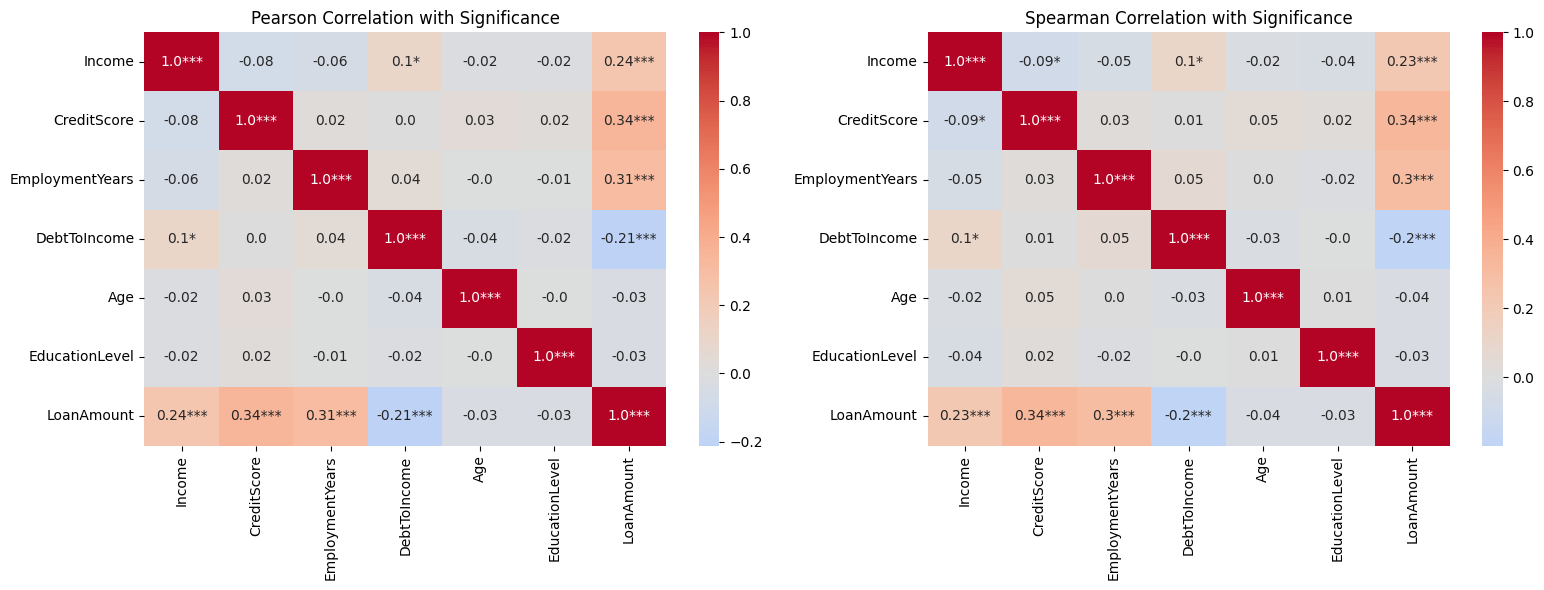

In [ ]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import qdesc as qd
import os

# Function to compute correlation matrix with p-values
def corr_with_pvalues(df, method="pearson"):
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=np.number)
    cols = numeric_df.columns
    corr_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)
    p_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            if method == "pearson":
                corr, p = pearsonr(numeric_df[cols[i]], numeric_df[cols[j]])
            else:
                corr, p = spearmanr(numeric_df[cols[i]], numeric_df[cols[j]])
            corr_matrix.iloc[i, j] = corr
            p_matrix.iloc[i, j] = p

    return corr_matrix, p_matrix

# Compute Pearson & Spearman correlations with p-values using df_encoded
pearson_corr, pearson_p = corr_with_pvalues(df_encoded, method="pearson")
spearman_corr, spearman_p = corr_with_pvalues(df_encoded, method="spearman")


# Function to add significance stars
def significance_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

# Build annotated heatmap labels for both Pearson and Spearman
pearson_annot = pearson_corr.round(2).astype(str)
for i in range(len(pearson_annot)):
    for j in range(len(pearson_annot)):
        star = significance_stars(pearson_p.iloc[i, j])
        pearson_annot.iloc[i, j] = pearson_annot.iloc[i, j] + star

spearman_annot = spearman_corr.round(2).astype(str)
for i in range(len(spearman_annot)):
    for j in range(len(spearman_annot)):
        star = significance_stars(spearman_p.iloc[i, j])
        spearman_annot.iloc[i, j] = spearman_annot.iloc[i, j] + star


# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_corr, annot=pearson_annot, cmap="coolwarm", center=0, fmt="", ax=axes[0])
axes[0].set_title("Pearson Correlation with Significance")

sns.heatmap(spearman_corr, annot=spearman_annot, cmap="coolwarm", center=0, fmt="", ax=axes[1])
axes[1].set_title("Spearman Correlation with Significance")

plt.tight_layout()
plt.show()

**Interpretation:**

1. LoanAmount is most influenced by:
*   CreditScore (strongest of the weak effects)
*   EmploymentYears
*   Income
*   DebtToIncome (negative)

>These make intuitive sense: lenders give larger loans to people with higher scores, steady employment, higher income, and lower debt burdens.

2. EducationLevel and Age are not influential in explaining financial outcomes here.

3. Pearson and Spearman results are consistent, meaning relationships are not only linear but also monotonic. This gives robustness to your findings.

4. Statistical vs. Practical significance:
*   Many correlations are statistically significant (probably due to large sample size).
*   But the effect sizes are weak (<0.4).

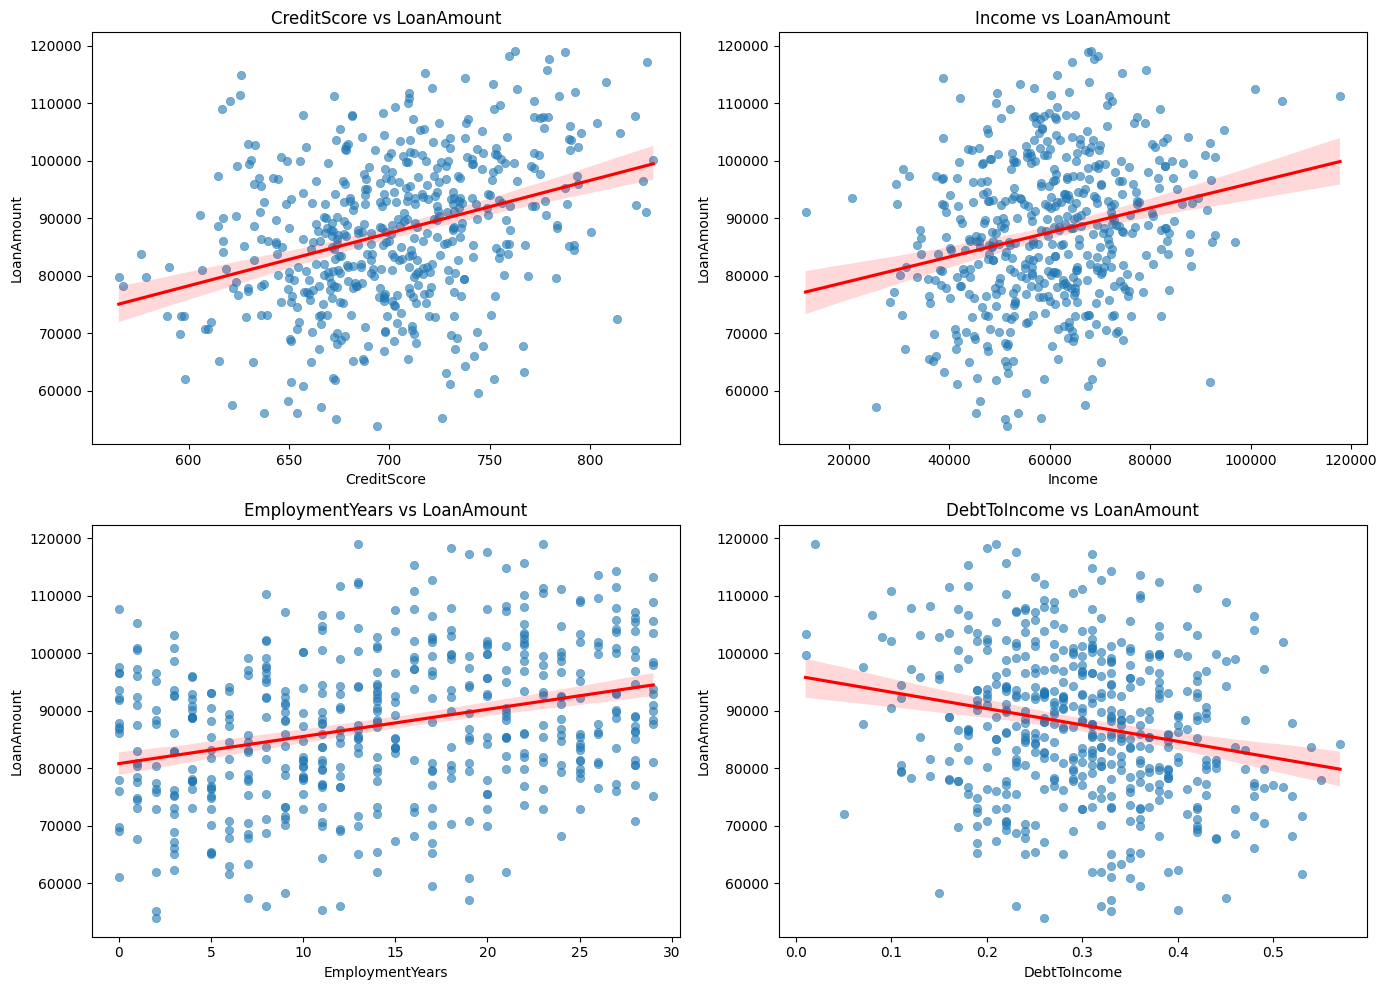

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only significant pairs with LoanAmount
sig_pairs = [
    ("CreditScore", "LoanAmount"),
    ("Income", "LoanAmount"),
    ("EmploymentYears", "LoanAmount"),
    ("DebtToIncome", "LoanAmount")
]

# Set up the figure
plt.figure(figsize=(14, 10))

for i, (x, y) in enumerate(sig_pairs, 1):
    plt.subplot(2, 2, i)  # 2x2 grid
    sns.scatterplot(data=df, x=x, y=y, alpha=0.6, edgecolor=None)
    sns.regplot(data=df, x=x, y=y, scatter=False, color="red")  # add regression line

    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.show()


**Interpretation:**

1. CreditScore vs LoanAmount


*   Trend: Clear positive slope — higher credit scores are associated with larger loan amounts.
*   Strength: Weak but significant correlation (≈0.34).

*   Insight: Borrowers with better creditworthiness (measured by credit score) are trusted with slightly larger loans. This matches real-world lending practices.

2. Income vs LoanAmount

*   Trend: Positive slope — as income increases, loan amount tends to increase.
*   Strength: Weak correlation (≈0.23–0.24).
*   Insight: Higher-income individuals qualify for higher loans. However, the scatter shows lots of variation → income alone is not a strong predictor of loan size.

3. EmploymentYears vs LoanAmount

*   Trend: Weak upward slope — more years of employment are weakly related to higher loan amounts.
*   Strength: Weak (≈0.30).
*   Insight: Stability in employment history has some influence, but again, the scatter is very dispersed — many long-tenured employees still take smaller loans, suggesting other factors matter more.

4. DebtToIncome vs LoanAmount

*   Trend: Negative slope — higher debt-to-income ratios are associated with smaller loan amounts.
*   Strength: Weak (≈-0.21).
*   Insight: This aligns with lending logic: if someone already has high debt relative to their income, lenders reduce the amount they’re willing to approve.


**Cross-Plot Insights:**

Loan approvals reflect practical lending logic:
*   Creditworthiness (CreditScore) → positive effect.
*   Financial capacity (Income & EmploymentYears) → positive effect.
*   Financial burden (DebtToIncome) → negative effect.

**Conclusion:**
*   LoanAmount is influenced most strongly by CreditScore, followed by EmploymentYears and Income, while DebtToIncome has a negative impact.

*   None of these variables alone explains loan amount strongly, suggesting a multifactor approach (like regression or machine learning) is needed to predict LoanAmount accurately.





# **Business Question from the Board**
“Which customer attributes most strongly drive the loan amount issued, and which are statistically significant?”

- CreditScore, EmploymentYears, Income (positive) and DebtToIncome (negative) are the statistically significant drivers in descending order of strength. Age and EducationLevel are not statistically meaningful.


# **Data & Methods**
- Data used: Internal loan application data with fields LoanAmount, Income, CreditScore, EmploymentYears, DebtToIncome, Age, EducationLevel.
- Preprocessing: Categorical fields (e.g., EducationLevel) converted to numeric codes (label encoding). Non-normal variables (EmploymentYears, Age) were noted.
- Normality checks: Anderson–Darling test + QQ plots, histograms, boxplots.
- Correlation analyses: Both Pearson (linear relationships) and Spearman (monotonic) were computed. P-values from correlation tests confirmed statistical significance.
Visualization: Scatterplots with regression lines for significant pairs.


# **Results**
Correlation & significance summary (rounded):
- LoanAmount ↔ CreditScore: r ≈ +0.34, p < 0.001 (weak → moderate, most impactful)
- LoanAmount ↔ EmploymentYears: r ≈ +0.30, p < 0.001 (weak)
- LoanAmount ↔ Income: r ≈ +0.24, p < 0.001 (weak)
- LoanAmount ↔ DebtToIncome: r ≈ -0.21, p < 0.001 (weak negative)
- LoanAmount ↔ Age: r ≈ 0 (negligible, not significant)
- LoanAmount ↔ EducationLevel: r ≈ 0 (negligible, not significant)

Notes:
Pearson and Spearman results were consistent. Statistical significance supported by small p-values. Large sample size amplifies ability to detect small effects even when effect size is modest.


# **Interpretation & Practical Meaning**

- CreditScore: Higher scores relate to larger approved loans, consistent with lending practice.
- EmploymentYears: Job stability rewarded; more years correlated with slightly higher loans.
- Income: Higher income helps but alone insufficient; scatter shows heterogeneity.
- DebtToIncome: Higher DTI reduces loan size, reflecting prudent risk controls.
- Age & Education: Negligible explanatory power; avoid as primary decision levers.

Note: Effect sizes are small — multiple features together are required to realistically explain LoanAmount.


# **Recommendations**
Short-term (0–4 weeks):
- Run multivariate regression or ML models to quantify combined effects.
- Quantify incremental contribution of each predictor.
- Investigate outliers.

Medium-term (1–3 months):
- Build a predictive scorecard.
- Pilot stricter DTI thresholds or score bands and monitor impact.
- Conduct fairness and compliance checks.

Long-term:
- Deploy automated decisioning with human-in-the-loop review.
- Establish model governance and drift monitoring.


# **Final Conclusion**
- Analysis shows CreditScore, EmploymentYears, Income (positive) and DebtToIncome (negative) as the primary statistically significant drivers of loan amount. Each driver on its own explains only a small portion of variance — hence observed scatter in the data and anomalies. The recommended path is to build a validated multivariable decision model combining these features with other operational variables, and pilot controlled automation with human-in-the-loop review and monitoring.
